# Day-ahead load forecasting — separate gradient-boosting models for PV and non-PV households

Builds on `baseline00.ipynb`: same task (aggregated load of all households for the 96 quarter-hours of day D, issued at
the day-ahead gate closure on D-1), same information set, same features, same chronological 80/20 split and the same
gradient-boosting model. **The only change:** the portfolio is split into households **with** and **without** a PV
system, one gradient-boosting model is trained per group, and the two group forecasts are added up.

**Why?** The meters only record the energy *drawn from the grid* (`kWh_received_Total`). Solar power that a PV household
consumes itself never reaches the meter, so on sunny days its midday grid draw collapses. A single model trained on the
portfolio mean has to average this load shape with the very different one of households without PV.

**Steps**
1. Setup & configuration
2. PV classification — survey flag from `households.csv` where available; for households without a flag the PV system
   is detected from the load pattern on sunny vs. overcast days, calibrated on the households with a flag
3. Data preparation per portfolio (all households / PV / no PV)
4. Gradient boosting: one model for all households (original approach) vs. one model per group (new approach)
5. Comparison on the 20% hold-out test period
6. Conclusions

**Forecast of the split approach**

`forecast_total(D, t) = ŷ_PV(D, t) · n_PV(D-1) + ŷ_noPV(D, t) · n_noPV(D-1)`

ŷ is the forecast load per household of the group, n the number of contracted group households known at gate closure —
the scaling of `_quick_test.ipynb`, applied per group. Both approaches are evaluated against the **same target** (the
aggregated portfolio load exactly as defined in `_quick_test.ipynb`) on the **same test days**.

## 1. Setup & configuration

In [9]:
import json
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.easter import easter
from IPython.display import display

import optuna
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import balanced_accuracy_score, precision_score, r2_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 40)


# ---------------- configuration: identical to _quick_test.ipynb ----------------
DATA = Path("data")
CACHE = DATA / "_cache"
RESULTS = Path("results")
CACHE.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

TZ = "Etc/GMT-1"         # fixed UTC+1 (no DST) -> every day has exactly 96 quarter-hours
STEPS = 96               # quarter-hours per day
MIN_HOUSEHOLDS = 50      # modelling period starts once at least this many households report
MAX_KWH_15MIN = 10.0     # single readings above 10 kWh / 15 min (= 40 kW) are meter errors -> dropped
TEST_SHARE = 0.2         # last 20% of the days = test set
GATE_SLOT = 44           # forecast is issued before quarter-hour 44 (11:00 UTC+1) of D-1
WX_SLOT_D1 = GATE_SLOT   # weather measurements of D-1 are known for quarter-hours < WX_SLOT_D1
METER_SLOT_D1 = 0        # meter readings of D-1 are known for quarter-hours < METER_SLOT_D1 (0 = daily read-out)
assert 0 <= METER_SLOT_D1 <= WX_SLOT_D1 <= STEPS and METER_SLOT_D1 % 4 == 0
N_FOLDS = 4              # expanding-window CV folds inside the training period ...
CV_VAL_DAYS = 91         # ... each validating one quarter
SEED = 42

# ---------------- PV classification ----------------
PV_LABEL_SOURCE = "metadata_first"  # "metadata_first": survey flag where available, detection only where it is missing
                                    # "detected_all":   detection for every household (groups by the observed load shape)
PV_INDICATOR = "midday_dip"         # indicator used for the detection: "midday_dip" or "sunny_june_ratio" (section 2.2)
SUMMER_MONTHS = [5, 6, 7, 8]
SUNNY_HOURS = 10                    # a day with >= 10 h of sunshine counts as sunny ...
OVERCAST_HOURS = 3                  # ... a day with <= 3 h as overcast
MIDDAY_UTC = (9, 15)                # midday window [09:00, 15:00) UTC = 10-16 h CET / 11-17 h CEST, around solar noon
MIN_INDICATOR_DAYS = 5              # an indicator needs at least this many sunny (and overcast) days

# ---------------- group models ----------------
MIN_HOUSEHOLDS_GROUP = 12           # a group's mean load is used if at least this many of its households report
                                    # (the PV group starts with ~15 households; 12 keeps every model day of _quick_test)
RUN_HPO = True                      # False -> reuse the group parameters stored in data/_cache/best_params_pv_split.json
N_TRIALS_GB = 10                    # Optuna trials per group (~1 min each); trial 0 = the parameters of the single model
                                    # 0 = no search: both groups use the parameters of the single model (fastest)
RUN_CV_COMPARISON = False           # True -> also compare both approaches on the CV folds of the training period (~5 min)

np.random.seed(SEED)

# ---------------- plotting (palette of _quick_test.ipynb) ----------------
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = PALETTE[:4]
C_GREY, C_INK = "#9a9994", "#0b0b0b"
GROUP_COLORS = {"PV": C_ORANGE, "no PV": C_AQUA, "flag missing": C_GREY}
SINGLE, SPLIT = "GB single model", "GB PV split"
MODEL_COLORS = {"Baseline (t-7d)": C_GREY, "Persistence": PALETTE[6], SINGLE: C_YELLOW, SPLIT: C_BLUE}
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (12, 4.5),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "grid.color": "#e6e5e0", "lines.linewidth": 2, "legend.frameon": False,
})
timings = {}

## 2. PV classification
### 2.1 Household data and survey flag
All 410 household files are read once (≈ 30 s) with exactly the filters of `_quick_test.ipynb` (duplicates removed,
readings outside 0–10 kWh / 15 min dropped). The per-household series are kept in memory: they are needed for the PV
indicators and for aggregating the two groups in section 3.

In [10]:
GRID = pd.date_range("2019-05-20", "2024-02-28", freq="15min", tz="UTC", inclusive="left")
t0 = time.time()
hh = {}                                  # Household_ID -> (grid positions, kWh) of every plausible reading
n_dropped = 0
for f in sorted((DATA / "15min").glob("*.csv")):      # same order and filters as section 2.1 of _quick_test.ipynb
    d = pd.read_csv(f, sep=";", usecols=["Timestamp", "kWh_received_Total"]).drop_duplicates("Timestamp")
    ts = pd.to_datetime(d.Timestamp, utc=True, format="%Y-%m-%d %H:%M:%S%z")
    pos = ((ts - GRID[0]) // pd.Timedelta("15min")).to_numpy()
    val = d.kWh_received_Total.to_numpy(dtype=float)
    inside = (pos >= 0) & (pos < len(GRID))
    ok = inside & ~np.isnan(val) & (val >= 0) & (val <= MAX_KWH_15MIN)
    n_dropped += int((inside & ((val < 0) | (val > MAX_KWH_15MIN))).sum())
    hh[int(f.stem)] = (pos[ok].astype(np.int32), val[ok])
timings["read households"] = time.time() - t0
empty = [h for h, (p, _) in hh.items() if len(p) == 0]
print(f"Read {len(hh)} households in {timings['read households']:.0f}s: "
      f"{sum(len(v) for _, v in hh.values()):,d} readings, {n_dropped} implausible readings dropped")
print(f"{len(empty)} households without a single plausible reading: {empty}")

META = DATA / "smart_meter_meta_data"
households = pd.read_csv(META / "households.csv", sep=";")
overview = pd.read_csv(META / "smart_meter_data_15min_overview.csv", sep=";")
assert set(households.Household_ID) == set(hh)
households["pv_meta"] = households.Installation_HasPVSystem.map({True: 1.0, False: 0.0, "True": 1.0, "False": 0.0})
hh_meta = households.set_index("Household_ID")
flag = hh_meta.pv_meta.map({1.0: "PV", 0.0: "no PV"}).fillna("flag missing").rename("PV flag (survey)")
pd.crosstab(flag, hh_meta.Group, margins=True, margins_name="total")

Read 410 households in 59s: 27,663,070 readings, 2 implausible readings dropped
4 households without a single plausible reading: [1065698, 747511, 768498, 996610]


Group,control,treatment,total
PV flag (survey),,,
PV,97,34,131
flag missing,161,4,165
no PV,0,114,114
total,258,152,410


### 2.2 Two PV indicators from the load pattern
Both indicators compare a household's grid draw on **sunny** days with a reference; a PV system lowers the grid draw
when the sun shines. Daily sunshine comes from the household's weather station; three stations do not measure sunshine,
their households use the mean of the other stations as proxy (the stations are close enough for daily sunshine to be
strongly correlated).

| Indicator | Definition | PV household | Weakness |
|---|---|---|---|
| `sunny_june_ratio` | mean load on sunny June days ÷ mean load over all days | low | also measures how much of the annual load is heating — this varies a lot between heat-pump households |
| `midday_dip` | midday share of the daily load on sunny summer days ÷ midday share on overcast summer days | ≪ 1 | needs sunny *and* overcast summer days |

`sunny_june_ratio` is the direct implementation of the idea "compare the load on sunny days with the overall load".
`midday_dip` refines it: it compares the household **with itself, in the same season and at the same time of day** —
heating share, household size and appliances cancel out and only the effect of the sun remains (≈ 1 without PV).
Both are computed on the UTC axis of the raw data; midday = 09–15 UTC (around solar noon).

In [11]:
UTC_DAYS = pd.date_range(GRID[0], periods=len(GRID) // STEPS, freq="D")
DAY_OF = np.arange(len(GRID)) // STEPS                  # grid position -> UTC day
HOUR_OF = (np.arange(len(GRID)) % STEPS) // 4           # grid position -> UTC hour
MONTH_OF = UTC_DAYS.month.to_numpy()                    # UTC day -> month

weather = pd.concat([pd.read_csv(f, sep=";") for f in sorted((DATA / "weather_data_hourly").glob("*.csv"))],
                    ignore_index=True)
weather["Timestamp"] = pd.to_datetime(weather.Timestamp, utc=True)
sun_day = (weather.groupby([weather.Timestamp.dt.floor("D"), "Weather_ID"]).Sunshine_duration_hourly
           .sum(min_count=20).unstack().reindex(UTC_DAYS))           # daily sunshine hours per station
no_sun = sun_day.columns[sun_day.isna().all()].tolist()
sun_proxy = sun_day.mean(axis=1)
sun_day = sun_day.apply(lambda c: c.fillna(sun_proxy))
print("Stations without sunshine measurements (proxy = mean of the other stations):", no_sun)


def pv_indicators(pos, val, sun):
    """Both PV indicators of one household. pos / val: its readings, sun: daily sunshine hours at its station."""
    out = {"sunny_june_ratio": np.nan, "midday_dip": np.nan, "sunny_days": 0, "overcast_days": 0}
    if len(val) == 0:
        return out
    day = DAY_OF[pos]
    s, month = sun[day], MONTH_OF[day]
    summer = np.isin(month, SUMMER_MONTHS)
    sunny, overcast = summer & (s >= SUNNY_HOURS), summer & (s <= OVERCAST_HOURS)
    june_sunny = (month == 6) & (s >= SUNNY_HOURS)
    midday = (HOUR_OF[pos] >= MIDDAY_UTC[0]) & (HOUR_OF[pos] < MIDDAY_UTC[1])
    n_days = lambda m: len(np.unique(day[m]))
    out["sunny_days"], out["overcast_days"] = n_days(sunny), n_days(overcast)
    with np.errstate(divide="ignore", invalid="ignore"):
        if n_days(june_sunny) >= MIN_INDICATOR_DAYS:
            out["sunny_june_ratio"] = val[june_sunny].mean() / val.mean()
        if min(out["sunny_days"], out["overcast_days"]) >= MIN_INDICATOR_DAYS:
            midday_share = lambda m: val[m & midday].sum() / val[m].sum()
            out["midday_dip"] = midday_share(sunny) / midday_share(overcast)
    return out


INDICATORS = ["sunny_june_ratio", "midday_dip"]
ind = pd.DataFrame.from_dict(
    {h: pv_indicators(p, v, sun_day[hh_meta.Weather_ID[h]].to_numpy()) for h, (p, v) in hh.items()}, orient="index")
ind = ind.replace([np.inf, -np.inf], np.nan).join(hh_meta[["pv_meta", "Weather_ID", "Group"]])
ind.index.name = "Household_ID"
ind.groupby(flag)[INDICATORS].agg(["median", "count"])

Stations without sunshine measurements (proxy = mean of the other stations): ['HbsbG', 'ceOxS', 'sV3mR']


sunny_june_ratio       midday_dip      
                           median count     median count
PV flag (survey)                                        
PV                         0.3455   118     0.3997   120
flag missing               0.5388   163     0.9759   164
no PV                      0.5141   107     0.9983   109

### 2.3 How well do the indicators recognise the known PV systems?
The 245 households **with** a survey flag serve as ground truth. Rule: *indicator < threshold → PV*. The threshold
maximises the balanced accuracy; its quality is estimated with a 5-fold cross-validation over households (the threshold
is chosen on 4/5 of the labelled households and tested on the remaining 1/5).

,ROC AUC,threshold,CV accuracy [%],CV balanced accuracy [%],CV precision PV [%],CV recall PV [%],labelled covered,unlabelled covered
sunny_june_ratio,0.711,0.404,66.7,67.1,72.6,58.5,225 / 245,163 / 165
midday_dip,0.829,0.731,80.3,81.2,97.5,64.2,229 / 245,164 / 165


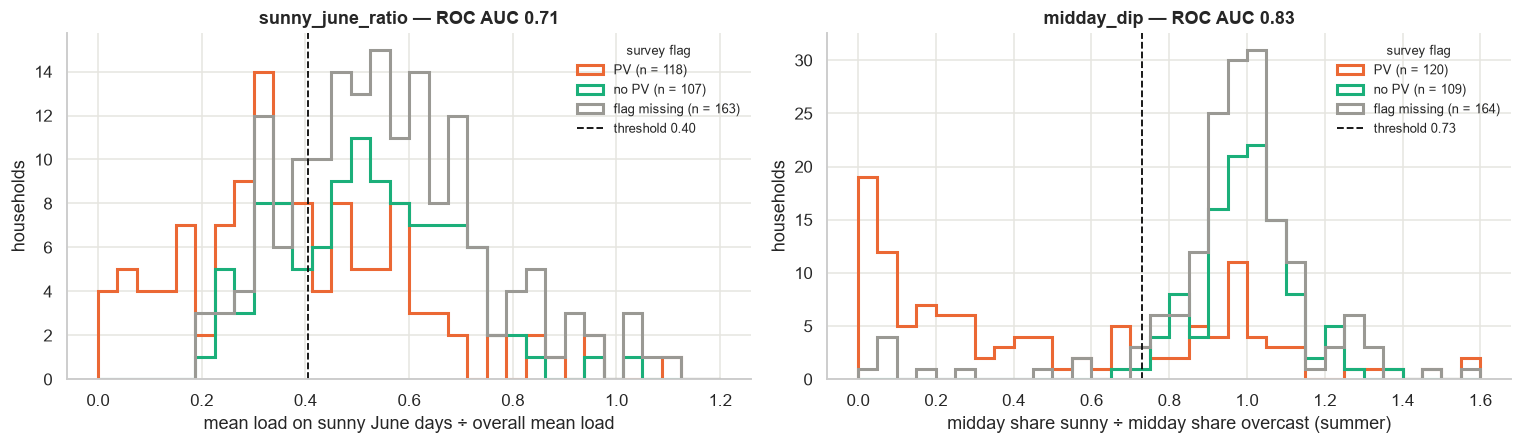

In [12]:
def best_threshold(x, y):
    """Threshold with the highest balanced accuracy for the rule 'indicator < threshold -> PV'."""
    cand = np.unique(x)
    cand = (cand[:-1] + cand[1:]) / 2
    return float(cand[np.argmax([balanced_accuracy_score(y, x < t) for t in cand])])


lab = ind[ind.pv_meta.notna()]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
ind_eval, thresholds = {}, {}
for name in INDICATORS:
    sub = lab[lab[name].notna()]
    x, y = sub[name].to_numpy(), sub.pv_meta.to_numpy() == 1
    cv_pred = np.zeros(len(x), dtype=bool)
    for tr, va in skf.split(x, y):
        cv_pred[va] = x[va] < best_threshold(x[tr], y[tr])
    thresholds[name] = best_threshold(x, y)
    ind_eval[name] = {
        "ROC AUC": f"{roc_auc_score(y, -x):.3f}", "threshold": f"{thresholds[name]:.3f}",
        "CV accuracy [%]": f"{100 * (cv_pred == y).mean():.1f}",
        "CV balanced accuracy [%]": f"{100 * balanced_accuracy_score(y, cv_pred):.1f}",
        "CV precision PV [%]": f"{100 * precision_score(y, cv_pred):.1f}",
        "CV recall PV [%]": f"{100 * recall_score(y, cv_pred):.1f}",
        "labelled covered": f"{len(sub)} / {len(lab)}",
        "unlabelled covered": f"{ind.loc[ind.pv_meta.isna(), name].notna().sum()} / {ind.pv_meta.isna().sum()}"}
display(pd.DataFrame(ind_eval).T)

RANGES = {"sunny_june_ratio": (0, 1.2), "midday_dip": (0, 1.6)}
XLABELS = {"sunny_june_ratio": "mean load on sunny June days ÷ overall mean load",
           "midday_dip": "midday share sunny ÷ midday share overcast (summer)"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, name in zip(axes, INDICATORS):
    lo, hi = RANGES[name]
    bins = np.linspace(lo, hi, 33)
    for label in ["PV", "no PV", "flag missing"]:
        x = ind.loc[flag == label, name].dropna().clip(lo, hi - 1e-9)
        ax.hist(x, bins=bins, histtype="step", lw=2, color=GROUP_COLORS[label], label=f"{label} (n = {len(x)})")
    ax.axvline(thresholds[name], color=C_INK, ls="--", lw=1.2, label=f"threshold {thresholds[name]:.2f}")
    ax.set_title(f"{name} — ROC AUC {float(ind_eval[name]['ROC AUC']):.2f}")
    ax.set_xlabel(XLABELS[name]); ax.set_ylabel("households"); ax.legend(fontsize=8.5, title="survey flag", title_fontsize=8.5)
plt.tight_layout(); plt.show()

**Interpretation**
* `sunny_june_ratio` separates the classes only weakly (ROC AUC ≈ 0.71, CV accuracy ≈ 67%): the June load relative to
  the annual mean mainly reflects how much of a household's consumption is heating, and that varies strongly between
  heat-pump households with and without PV.
* `midday_dip` is clearly better (ROC AUC ≈ 0.83, CV balanced accuracy ≈ 81%) and above all **precise**: almost every
  household it flags as PV really has a PV system (CV precision ≈ 97%), and not a single household without PV shows a
  pronounced dip. Its recall is only ≈ 64% because about a third of the households with a PV flag show **no dip at all**
  (indicator ≈ 1, exactly like households without PV) — most likely systems that feed their entire output into the grid
  or are metered separately, so the meter in this dataset does not see them. From the forecasting point of view these
  households behave like households without PV.
* The survey flag is only ever `True` or missing in the control group (see 2.1), i.e. a missing flag there probably
  means *no PV*. The detection agrees: only a small minority of the unlabelled households show a PV dip.

→ `PV_INDICATOR = "midday_dip"` with the threshold above is used for the households without a flag.

### 2.4 Final PV assignment
With `PV_LABEL_SOURCE = "metadata_first"` the survey flag is kept wherever it exists and the indicator selected in
`PV_INDICATOR` (with the threshold from 2.3) decides only for households without a flag. A household for which neither
exists (no plausible readings at all) gets the class that the detection assigns to the majority of the unlabelled
households. The assignment is saved to `results/pv_classification.csv`.

In [13]:
thr = thresholds[PV_INDICATOR]
x = ind[PV_INDICATOR]
ind["pv_detected"] = (x < thr).astype(float).where(x.notna())
fallback = float(ind.loc[ind.pv_meta.isna(), "pv_detected"].mean() >= 0.5)
if PV_LABEL_SOURCE == "metadata_first":
    primary, secondary, names = ind.pv_meta, ind.pv_detected, ["metadata", "detected"]
elif PV_LABEL_SOURCE == "detected_all":
    primary, secondary, names = ind.pv_detected, ind.pv_meta, ["detected", "metadata"]
else:
    raise ValueError(f"unknown PV_LABEL_SOURCE {PV_LABEL_SOURCE!r}")
ind["pv_source"] = np.select([primary.notna(), secondary.notna()], names, default="fallback")
ind["pv"] = primary.fillna(secondary).fillna(fallback).astype(bool)
ind["pv_group"] = ind.pv.map({True: "PV", False: "no PV"})
print(f"Indicator: {PV_INDICATOR}, threshold {thr:.3f} | fallback class: {'PV' if fallback else 'no PV'}")
display(pd.crosstab(ind.pv_source, ind.pv_group, margins=True, margins_name="total")
        .rename_axis(index="source of the label", columns="final group"))

both = ind.pv_meta.notna() & ind.pv_detected.notna()
print("Detection vs. survey flag on the labelled households (in-sample):")
display(pd.crosstab(flag[both], ind.pv_detected[both].map({1.0: "PV", 0.0: "no PV"}).rename("detected")))
ind.to_csv(RESULTS / "pv_classification.csv")

Indicator: midday_dip, threshold 0.731 | fallback class: no PV


final group,PV,no PV,total
source of the label,,,
detected,11,153,164
fallback,0,1,1
metadata,131,114,245
total,142,268,410


Detection vs. survey flag on the labelled households (in-sample):


detected,PV,no PV
PV flag (survey),,
PV,79,41
no PV,1,108


### 2.5 Plausibility check: daily load profiles
Average daily profile on sunny and on overcast summer days (each household normalised to its own daily mean, so
households of different size weigh equally). Solid = label from the survey, dashed = label from the detection.

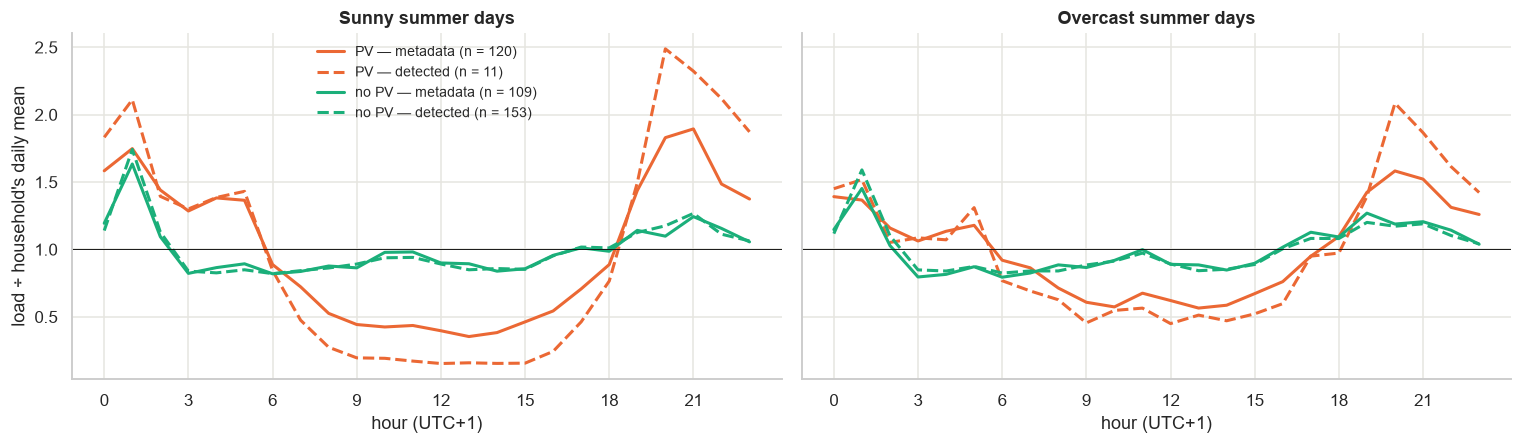

In [14]:
def mean_profile(ids, sunny):
    """Average normalised hourly profile (UTC+1) of the households `ids` on sunny / overcast summer days."""
    profiles = []
    for h in ids:
        pos, val = hh[h]
        day = DAY_OF[pos]
        s = sun_day[hh_meta.Weather_ID[h]].to_numpy()[day]
        m = np.isin(MONTH_OF[day], SUMMER_MONTHS) & ((s >= SUNNY_HOURS) if sunny else (s <= OVERCAST_HOURS))
        if len(np.unique(day[m])) < MIN_INDICATOR_DAYS:
            continue
        hour = HOUR_OF[pos][m]
        p = np.bincount(hour, weights=val[m], minlength=24) / np.maximum(np.bincount(hour, minlength=24), 1)
        if p.mean() > 0:
            profiles.append(np.roll(p / p.mean(), 1))                   # UTC -> UTC+1
    return (np.mean(profiles, axis=0) if profiles else None), len(profiles)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for ax, sunny in zip(axes, [True, False]):
    for grp in ["PV", "no PV"]:
        for src, ls in [("metadata", "-"), ("detected", "--")]:
            prof, n = mean_profile(ind.index[(ind.pv_group == grp) & (ind.pv_source == src)], sunny)
            if prof is not None:
                ax.plot(np.arange(24), prof, color=GROUP_COLORS[grp], ls=ls, label=f"{grp} — {src} (n = {n})")
    ax.axhline(1, color=C_INK, lw=.6)
    ax.set_title(f"{'Sunny' if sunny else 'Overcast'} summer days"); ax.set_xlabel("hour (UTC+1)")
    ax.set_xticks(range(0, 24, 3))
axes[0].set_ylabel("load ÷ household's daily mean"); axes[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 3. Data preparation per portfolio
Sections 2.1–2.5 of `_quick_test.ipynb` are wrapped into functions and run for three portfolios:
**all households** (the original target), **PV** and **no PV**. Per group,
* the target is the mean load per reporting **group** household (valid if ≥ `MIN_HOUSEHOLDS_GROUP` report; missing
  meters are therefore imputed with the mean of their own group),
* the contracted households are counted per group,
* the weather is weighted with the group's households per station,
* the features are the same 33 features, computed from the group's own load history.

The modelling period is the same for all portfolios (from the first day with ≥ `MIN_HOUSEHOLDS` reporting households).

In [15]:
ov = overview.merge(households[["Household_ID", "Weather_ID"]], on="Household_ID")
ov["first_day"] = pd.to_datetime(ov.SMD_15min_TimeAvailable_EarliestTimestamp, utc=True).dt.tz_convert(TZ).dt.floor("D")
ov["last_day"] = pd.to_datetime(ov.SMD_15min_TimeAvailable_LatestTimestamp, utc=True).dt.tz_convert(TZ).dt.floor("D")
STATIONS = sorted(ov.Weather_ID.unique())
all_days = pd.date_range(ov.first_day.min(), ov.last_day.max(), freq="D")
WX_MAP = {"Temperature_avg_hourly": "temp", "Sunshine_duration_hourly": "sunshine",
          "Humidity_avg_hourly": "humidity", "WindSpeed_hourly": "wind"}
wx_local = weather.assign(Timestamp=weather.Timestamp.dt.tz_convert(TZ))
WX_UP = {}                                   # hourly station data held for its four quarter-hours (causal)
for raw, name in WX_MAP.items():
    wide = wx_local.pivot_table(index="Timestamp", columns="Weather_ID", values=raw).asfreq("h")
    WX_UP[name] = wide.resample("15min").asfreq().ffill(limit=3)


def aggregate(members):
    """Sum and number of reporting households per quarter-hour (section 2.1 of _quick_test.ipynb for a subset)."""
    members = set(members)
    s_sum, s_cnt = np.zeros(len(GRID)), np.zeros(len(GRID))
    for h, (pos, val) in hh.items():                     # file order of _quick_test.ipynb -> bit-identical sums
        if h in members:
            s_sum += np.bincount(pos, weights=val, minlength=len(GRID))
            s_cnt += np.bincount(pos, minlength=len(GRID))
    return pd.DataFrame({"sum": s_sum, "n": s_cnt.astype(np.int32)}, index=GRID).tz_convert(TZ)


def contracted(members):
    """Contracted households per day and weather station (section 2.2 of _quick_test.ipynb for a subset)."""
    n_st = pd.DataFrame(0, index=all_days, columns=STATIONS)
    for r in ov[ov.Household_ID.isin(members)].itertuples():
        n_st.loc[r.first_day:r.last_day, r.Weather_ID] += 1
    return n_st


def portfolio_weighted(wide, n_contract_st):
    W = n_contract_st.reindex(wide.index.floor("D")).fillna(0).to_numpy(float)
    V = wide.reindex(columns=n_contract_st.columns).to_numpy(float)
    W = np.where(np.isnan(V), 0.0, W)
    with np.errstate(invalid="ignore", divide="ignore"):
        return pd.Series(np.nansum(V * W, axis=1) / W.sum(axis=1), index=wide.index)


def ch_holidays(years):
    # Swiss national / widespread public holidays
    out = set()
    for y in years:
        e = pd.Timestamp(easter(y))
        out |= {pd.Timestamp(y, 1, 1), pd.Timestamp(y, 1, 2), e - pd.Timedelta(days=2), e + pd.Timedelta(days=1),
                e + pd.Timedelta(days=39), e + pd.Timedelta(days=50), pd.Timestamp(y, 8, 1),
                pd.Timestamp(y, 12, 25), pd.Timestamp(y, 12, 26)}
    return out


flat = lambda m: np.asarray(m, dtype=float).ravel()          # (days, 96) -> day-major vector
per_day = lambda s: np.repeat(np.asarray(s, dtype=float), STEPS)


def latest_known(M, n_known_d1):
    """Same quarter-hour on the most recent day on which it is known at forecast time (D-1 / D-2)."""
    known = np.arange(STEPS) < n_known_d1
    return pd.DataFrame(np.where(known, M.shift(1).to_numpy(), M.shift(2).to_numpy()), index=M.index)


def trailing(x, window, n_known_d1, how="mean"):
    """Statistic over the last `window` quarter-hours known at forecast time, one value per target day D."""
    r = getattr(pd.Series(x).rolling(window, min_periods=window), how)().to_numpy()
    end = (np.arange(N_DAYS) - 1) * STEPS + n_known_d1 - 1
    out = np.full(N_DAYS, np.nan)
    out[end >= 0] = r[end[end >= 0]]
    return pd.Series(out, index=day_index)


def make_features(Ymat, Yhist, Wx, n_contract):
    """Feature table of section 2.5 of _quick_test.ipynb: one row per (target day D, quarter-hour)."""
    H_FLAT = Yhist.to_numpy().ravel()
    WX_FLAT = {c: m.to_numpy().ravel() for c, m in Wx.items()}
    tab = pd.DataFrame(index=pd.MultiIndex.from_product([day_index, range(STEPS)], names=["day", "slot"]))
    tab["y"] = flat(Ymat)
    # ---- load history known at forecast time
    tab["lag_recent"] = flat(latest_known(Yhist, METER_SLOT_D1))
    tab["lag_2d"] = flat(Yhist.shift(2))
    tab["lag_7d"] = flat(Yhist.shift(7))
    tab["load_mean_24h"] = per_day(trailing(H_FLAT, STEPS, METER_SLOT_D1))
    tab["load_mean_7d"] = per_day(trailing(H_FLAT, 7 * STEPS, METER_SLOT_D1))
    tab["load_max_24h"] = per_day(trailing(H_FLAT, STEPS, METER_SLOT_D1, "max"))
    tab["load_last"] = per_day(trailing(H_FLAT, 1, METER_SLOT_D1))
    # ---- weather measured until the forecast time
    t_mean = trailing(WX_FLAT["temp"], STEPS, WX_SLOT_D1)
    tab["temp_recent"] = flat(latest_known(Wx["temp"], WX_SLOT_D1))
    tab["sunshine_recent"] = flat(latest_known(Wx["sunshine"], WX_SLOT_D1))
    tab["temp_mean_24h"] = per_day(t_mean)
    tab["temp_min_24h"] = per_day(trailing(WX_FLAT["temp"], STEPS, WX_SLOT_D1, "min"))
    tab["temp_max_24h"] = per_day(trailing(WX_FLAT["temp"], STEPS, WX_SLOT_D1, "max"))
    tab["hdd_24h"] = per_day((20 - t_mean).where(t_mean < 12, 0).where(t_mean.notna()))
    tab["sunshine_24h"] = per_day(trailing(WX_FLAT["sunshine"], STEPS, WX_SLOT_D1, "sum") / 4)
    tab["humidity_24h"] = per_day(trailing(WX_FLAT["humidity"], STEPS, WX_SLOT_D1))
    tab["wind_24h"] = per_day(trailing(WX_FLAT["wind"], STEPS, WX_SLOT_D1))
    tab["temp_last"] = per_day(trailing(WX_FLAT["temp"], 1, WX_SLOT_D1))
    tab["temp_trend"] = per_day(t_mean - t_mean.shift(1))
    tab["temp_mean_7d"] = per_day(trailing(WX_FLAT["temp"], 7 * STEPS, WX_SLOT_D1))
    # ---- calendar (identical for all portfolios)
    for c in CAL.columns:
        tab[c] = CAL[c].to_numpy()
    # ---- bookkeeping (not features)
    nc = n_contract.reindex(day_index)
    tab["n_contract"] = per_day(nc)                         # true portfolio size of D (target only)
    tab["n_contract_prev"] = per_day(nc.shift(1))          # portfolio size known at forecast time
    tab["total"] = tab.y * tab.n_contract
    tab["baseline_total"] = flat(Yhist.shift(7)) * per_day(nc.shift(7))
    tab["persist_total"] = tab.lag_recent * tab.n_contract_prev
    return tab


def build_portfolio(agg15, n_contract_st, min_n):
    """Sections 2.2-2.5 of _quick_test.ipynb for one portfolio: target, weather, day matrices, feature table."""
    n_contract = n_contract_st.sum(axis=1)
    df = agg15.loc[start_day: last_day + pd.Timedelta(hours=23, minutes=45)].copy()
    df["mean_kwh"] = df["sum"] / df["n"].where(df["n"] >= min_n)       # load per reporting household
    df["mean_kwh_hist"] = df.mean_kwh.ffill(limit=8)                   # causal copy for the features
    na = df.mean_kwh.isna()                                            # target: interpolate gaps <= 2 h
    run_len = na.groupby((na != na.shift()).cumsum()).transform("sum")
    fill = na & (run_len <= 8)
    df.loc[fill, "mean_kwh"] = df.mean_kwh.interpolate(limit_area="inside")[fill]
    df["n_contract"] = n_contract.reindex(df.index.floor("D")).to_numpy()
    df["total_kwh"] = df.mean_kwh * df.n_contract
    for name, up in WX_UP.items():
        df[name] = portfolio_weighted(up, n_contract_st).reindex(df.index).to_numpy()
    daymat = lambda col: pd.DataFrame(df[col].to_numpy(dtype=float).reshape(N_DAYS, STEPS), index=day_index)
    Wx = {c: daymat(c) for c in WX_MAP.values()}
    Ymat = daymat("mean_kwh")
    day_ok = Ymat.notna().all(axis=1)
    Ymat = Ymat.where(day_ok)
    Yhist = daymat("mean_kwh_hist").ffill(limit=1)
    hist_ok = Yhist.notna().all(axis=1).astype(float)
    usable = day_ok & (hist_ok.shift(1).rolling(HIST_DAYS).sum() == HIST_DAYS)
    return SimpleNamespace(df=df, Wx=Wx, Ymat=Ymat, Yhist=Yhist, day_ok=day_ok, usable=usable, n_fill=int(fill.sum()),
                           n_contract=n_contract, n_contract_st=n_contract_st,
                           tab=make_features(Ymat, Yhist, Wx, n_contract))

In [16]:
GROUPS = {"all": list(hh), "PV": ind.index[ind.pv].tolist(), "no PV": ind.index[~ind.pv].tolist()}
t0 = time.time()
agg = {g: aggregate(m) for g, m in GROUPS.items()}
AGG_FILE = CACHE / "portfolio_15min.pkl"
if AGG_FILE.exists():
    print("Aggregate of all households identical to the cache of _quick_test.ipynb:",
          pd.read_pickle(AGG_FILE).tz_convert(TZ).equals(agg["all"]))

# modelling period and calendar: identical to _quick_test.ipynb
daily_min_n = agg["all"].n.resample("D").min()
start_day = daily_min_n[daily_min_n >= MIN_HOUSEHOLDS].index[0]
last_day = (agg["all"].index[-1] + pd.Timedelta("15min")).floor("D") - pd.Timedelta(days=1)
day_index = pd.date_range(start_day, last_day, freq="D")
N_DAYS = len(day_index)
HIST_DAYS = 7 if METER_SLOT_D1 == STEPS else 8

naive_days = day_index.tz_localize(None)
HOLIDAYS = ch_holidays(range(day_index[0].year, day_index[-1].year + 1))
slot = np.tile(np.arange(STEPS), N_DAYS)
offday = pd.Series(((naive_days.dayofweek >= 5) | naive_days.isin(HOLIDAYS)).astype(float), index=day_index)
dow = naive_days.dayofweek.to_numpy()
doy = naive_days.dayofyear.to_numpy()
CAL = pd.DataFrame({
    "slot": slot, "hour": slot // 4,
    "tod_sin": np.sin(2 * np.pi * slot / STEPS), "tod_cos": np.cos(2 * np.pi * slot / STEPS),
    "dow": per_day(dow), "dow_sin": per_day(np.sin(2 * np.pi * dow / 7)), "dow_cos": per_day(np.cos(2 * np.pi * dow / 7)),
    "is_weekend": per_day(dow >= 5), "is_holiday": per_day(naive_days.isin(HOLIDAYS)),
    "is_xmas": per_day(((naive_days.month == 12) & (naive_days.day >= 24)) | ((naive_days.month == 1) & (naive_days.day <= 6))),
    "doy_sin": per_day(np.sin(2 * np.pi * doy / 365.25)), "doy_cos": per_day(np.cos(2 * np.pi * doy / 365.25)),
    "is_dst": per_day([pd.Timestamp(f"{d:%Y-%m-%d} 12:00", tz="Europe/Zurich").dst() != pd.Timedelta(0) for d in naive_days]),
    "offday_d1": per_day(offday.shift(1)), "offday_d2": per_day(offday.shift(2)), "offday_d7": per_day(offday.shift(7)),
})

LAG_COLS = ["lag_recent", "lag_2d", "lag_7d", "load_mean_24h", "load_mean_7d", "load_max_24h", "load_last"]
if METER_SLOT_D1 == 0:
    LAG_COLS.remove("lag_2d")                    # identical to lag_recent when no meter data of D-1 are known
WX_PAST_COLS = ["temp_recent", "sunshine_recent", "temp_mean_24h", "temp_min_24h", "temp_max_24h",
                "hdd_24h", "sunshine_24h", "humidity_24h", "wind_24h", "temp_last", "temp_trend", "temp_mean_7d"]
CAL_COLS = ["slot", "tod_sin", "tod_cos", "dow", "dow_sin", "dow_cos", "is_weekend", "is_holiday", "is_xmas",
            "doy_sin", "doy_cos", "is_dst", "offday_d1", "offday_d2", "offday_d7"]
FEATURES = LAG_COLS + WX_PAST_COLS + CAL_COLS

P = {g: build_portfolio(agg[g], contracted(m), MIN_HOUSEHOLDS if g == "all" else MIN_HOUSEHOLDS_GROUP)
     for g, m in GROUPS.items()}
timings["data preparation"] = time.time() - t0

ov_tab = pd.DataFrame({g: {
    "households": len(GROUPS[g]),
    "contracted on first day": int(p.n_contract.reindex(day_index).iloc[0]),
    "contracted on last day": int(p.n_contract.reindex(day_index).iloc[-1]),
    "min. reporting households (valid days)": int(p.df.n[np.repeat(p.day_ok.to_numpy(), STEPS)].min()),
    "valid target days": int(p.day_ok.sum()),
    "usable days (incl. history)": int(p.usable.sum()),
    "interpolated quarter-hours": p.n_fill,
    "mean load / household [kWh/day]": STEPS * p.df.mean_kwh.mean(),
} for g, p in P.items()})
print(f"Modelling period: {start_day:%Y-%m-%d} -> {last_day:%Y-%m-%d} ({N_DAYS} days), {len(FEATURES)} features")
display(ov_tab.style.format(lambda v: f"{v:,.0f}" if float(v).is_integer() else f"{v:,.2f}"))

# how much does the target change if missing meters are imputed with the group mean instead of the portfolio mean?
tot_split = P["PV"].df.total_kwh + P["no PV"].df.total_kwh
both_ok = tot_split.notna() & P["all"].df.total_kwh.notna()
print(f"Sum of the two group targets vs. original target: mean abs. difference "
      f"{100 * (tot_split - P['all'].df.total_kwh)[both_ok].abs().sum() / P['all'].df.total_kwh[both_ok].sum():.2f}% "
      f"of the load (both approaches are evaluated against the original target)")

Aggregate of all households identical to the cache of _quick_test.ipynb: True
Modelling period: 2020-11-04 -> 2024-02-27 (1211 days), 33 features


,all,PV,no PV
households,410,142,268
contracted on first day,54,17,37
contracted on last day,380,131,249
min. reporting households (valid days),50,14,34
valid target days,"1,205","1,207","1,207"
usable days (incl. history),"1,197","1,199","1,199"
interpolated quarter-hours,0,0,0
mean load / household [kWh/day],30.68,27.17,32.11


Sum of the two group targets vs. original target: mean abs. difference 0.25% of the load (both approaches are evaluated against the original target)


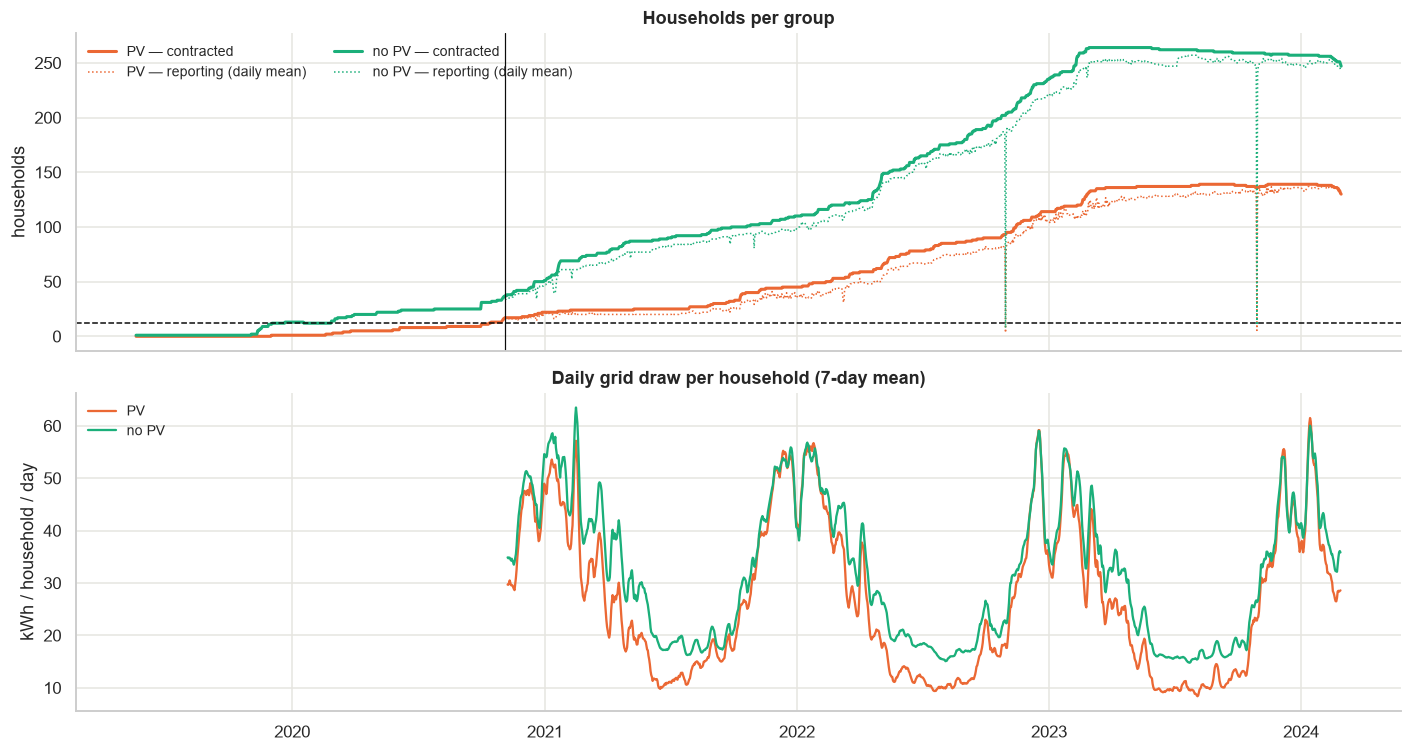

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for g in ["PV", "no PV"]:
    p = P[g]
    axes[0].plot(all_days, p.n_contract.reindex(all_days), color=GROUP_COLORS[g], label=f"{g} — contracted")
    axes[0].plot(day_index, p.df.n.resample("D").mean(), color=GROUP_COLORS[g], lw=1, ls=":",
                 label=f"{g} — reporting (daily mean)")
    daily = (p.df.mean_kwh.resample("D").sum(min_count=STEPS)).rolling(7, min_periods=5).mean()
    axes[1].plot(daily.index, daily, color=GROUP_COLORS[g], lw=1.5, label=g)
axes[0].axhline(MIN_HOUSEHOLDS_GROUP, color=C_INK, ls="--", lw=1)
axes[0].axvline(start_day, color=C_INK, lw=.8)
axes[0].set_ylabel("households"); axes[0].set_title("Households per group"); axes[0].legend(fontsize=9, ncol=2)
axes[1].set_ylabel("kWh / household / day"); axes[1].set_title("Daily grid draw per household (7-day mean)")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### 3.1 Train / test split (80 / 20, chronological)
A day is used only if the target and the full feature history are valid for **all three** portfolios, so both approaches
are trained and tested on identical days. The expanding-window CV folds are built exactly as in `_quick_test.ipynb`.

In [18]:
def complete_days(p, cols):
    ok = p.tab[cols].notna().all(axis=1).groupby(level="day").all().reindex(day_index).fillna(False)
    return (ok & p.usable).to_numpy()


BASE_COLS = FEATURES + ["y", "total", "n_contract_prev"]
orig_ok = complete_days(P["all"], BASE_COLS + ["baseline_total", "persist_total"])    # = model days of _quick_test
common_ok = orig_ok & complete_days(P["PV"], BASE_COLS) & complete_days(P["no PV"], BASE_COLS)
model_days = day_index[common_ok]
print(f"Model days: {orig_ok.sum()} in _quick_test.ipynb -> {common_ok.sum()} with valid data for both groups as well")
n_test = int(round(len(model_days) * TEST_SHARE))
train_days, test_days = model_days[:-n_test], model_days[-n_test:]
train = {g: p.tab.loc[train_days] for g, p in P.items()}
test = {g: p.tab.loc[test_days] for g, p in P.items()}

train_day_pos = pd.Series(np.arange(len(train_days)), index=train_days)
row_pos = train_day_pos.reindex(train["all"].index.get_level_values("day")).to_numpy()
folds = [(np.flatnonzero(np.isin(row_pos, tr)), np.flatnonzero(np.isin(row_pos, va)))
         for tr, va in TimeSeriesSplit(n_splits=N_FOLDS, test_size=CV_VAL_DAYS).split(np.arange(len(train_days)))]

display(pd.DataFrame({
    "days": [len(train_days), len(test_days)],
    "from": [train_days[0].date(), test_days[0].date()], "to": [train_days[-1].date(), test_days[-1].date()],
    **{f"mean load / household {g} [kWh/15min]": [train[g].y.mean(), test[g].y.mean()] for g in GROUPS},
}, index=["train (80%)", "test (20%)"]))
fold_days = []
for k, (tr, va) in enumerate(folds):
    d_tr, d_va = train_days[np.unique(row_pos[tr])], train_days[np.unique(row_pos[va])]
    fold_days.append(f"{d_va[0]:%Y-%m-%d} → {d_va[-1]:%Y-%m-%d}")
    print(f"CV fold {k + 1}: train {d_tr[0]:%Y-%m-%d} → {d_tr[-1]:%Y-%m-%d} ({len(d_tr)} d) | validate {fold_days[-1]}")

Model days: 1197 in _quick_test.ipynb -> 1197 with valid data for both groups as well


,days,from,to,mean load / household all [kWh/15min],mean load / household PV [kWh/15min],mean load / household no PV [kWh/15min]
train (80%),958,2020-11-12,2023-07-01,0.3250,0.2859,0.3398
test (20%),239,2023-07-02,2024-02-27,0.2975,0.2700,0.3119


CV fold 1: train 2020-11-12 → 2022-06-30 (594 d) | validate 2022-07-01 → 2022-09-29
CV fold 2: train 2020-11-12 → 2022-09-29 (685 d) | validate 2022-09-30 → 2022-12-31
CV fold 3: train 2020-11-12 → 2022-12-31 (776 d) | validate 2023-01-01 → 2023-04-01
CV fold 4: train 2020-11-12 → 2023-04-01 (867 d) | validate 2023-04-02 → 2023-07-01


## 4. Gradient boosting
### 4.1 Hyperparameters
* **Single model (original approach):** the parameters tuned in `_quick_test.ipynb` (`data/_cache/best_params.json`)
  are reused unchanged, so this model *is* the gradient boosting of `_quick_test.ipynb`.
* **Group models:** each group gets its own Optuna search with the same search space, expanding-window CV and pruning
  as in `_quick_test.ipynb`. Trial 0 is the single model's parameter set, so a group only deviates from it if other
  parameters are better in the cross-validation. CV errors are weighted with the group's portfolio size of the day.
  With `N_TRIALS_GB = 0` there is no search and both groups use the single model's parameters.

In [19]:
def mae(a, b, w=None):
    return float(np.average(np.abs(np.asarray(a) - np.asarray(b)), weights=w))


def cv_mae(make_model, X, y, w, trial=None):
    # mean validation MAE over the expanding-window folds; with `trial` every fold is reported to Optuna for pruning
    scores = []
    for k, (tr, va) in enumerate(folds):
        model = make_model().fit(X.iloc[tr], y[tr])
        scores.append(mae(y[va], model.predict(X.iloc[va]), w[va]))
        if trial is not None:
            trial.report(float(np.mean(scores)), k)
            if trial.should_prune():
                raise optuna.TrialPruned()
    if trial is not None:
        trial.set_user_attr("fold_mae", scores)
    return float(np.mean(scores))


def gb_from(p):
    return HistGradientBoostingRegressor(loss=p["loss"], learning_rate=p["learning_rate"], max_iter=p["max_iter"],
                                         max_leaf_nodes=p["max_leaf_nodes"], min_samples_leaf=p["min_samples_leaf"],
                                         l2_regularization=p["l2_regularization"], early_stopping=False,
                                         random_state=SEED)


def suggest_gb(trial):
    return {"loss": trial.suggest_categorical("loss", ["squared_error", "absolute_error"]),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
            "max_iter": trial.suggest_int("max_iter", 100, 1000, log=True),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 127, log=True),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 1000, log=True),
            "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True)}


def tune_gb(g):
    X, y, w = train[g][FEATURES], train[g].y.to_numpy(), train[g].n_contract_prev.to_numpy()

    def objective(trial):
        p = suggest_gb(trial)
        return cv_mae(lambda: gb_from(p), X, y, w, trial)

    study = optuna.create_study(direction="minimize",
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
                                sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True, n_startup_trials=10))
    study.enqueue_trial(START_PARAMS)
    study.optimize(objective, n_trials=N_TRIALS_GB)
    trials = study.trials_dataframe()[["number", "value", "state"] + [f"params_{k}" for k in study.best_params]]
    return {"params": study.best_params, "cv_folds": study.best_trial.user_attrs["fold_mae"],
            "trials": trials.rename(columns=lambda c: c.replace("params_", "")).to_dict("list")}


ORIG_FILE, PARAM_FILE = CACHE / "best_params.json", CACHE / "best_params_pv_split.json"
orig_params = json.loads(ORIG_FILE.read_text()).get("gradient_boosting") if ORIG_FILE.exists() else None
split_params = json.loads(PARAM_FILE.read_text()) if PARAM_FILE.exists() else {}
START_PARAMS = orig_params or {"loss": "squared_error", "learning_rate": 0.05, "max_iter": 400, "max_leaf_nodes": 31,
                               "min_samples_leaf": 100, "l2_regularization": 1.0}
gb_params = {"all": orig_params} if orig_params else {}
for g in GROUPS:
    if g in gb_params:
        continue
    if N_TRIALS_GB == 0:                         # no search: the groups use the parameters of the single model
        gb_params[g] = START_PARAMS
        continue
    if RUN_HPO or g not in split_params:
        t0 = time.time()
        split_params[g] = tune_gb(g)
        PARAM_FILE.write_text(json.dumps(split_params, indent=2))
        timings[f"HPO {g}"] = time.time() - t0
        print(f"{g}: {N_TRIALS_GB} trials in {timings[f'HPO {g}'] / 60:.1f} min")
    gb_params[g] = split_params[g]["params"]
print("Single model:", "parameters of _quick_test.ipynb" if orig_params else "tuned here (no best_params.json found)")
display(pd.DataFrame(gb_params).T.rename_axis("model"))

PV: 10 trials in 6.1 min
no PV: 10 trials in 7.2 min
Single model: parameters of _quick_test.ipynb


,loss,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization
model,,,,,,
all,absolute_error,0.0278,997,44,762,0.0166
PV,absolute_error,0.0226,211,34,57,1.3922
no PV,absolute_error,0.0278,997,44,762,0.0166


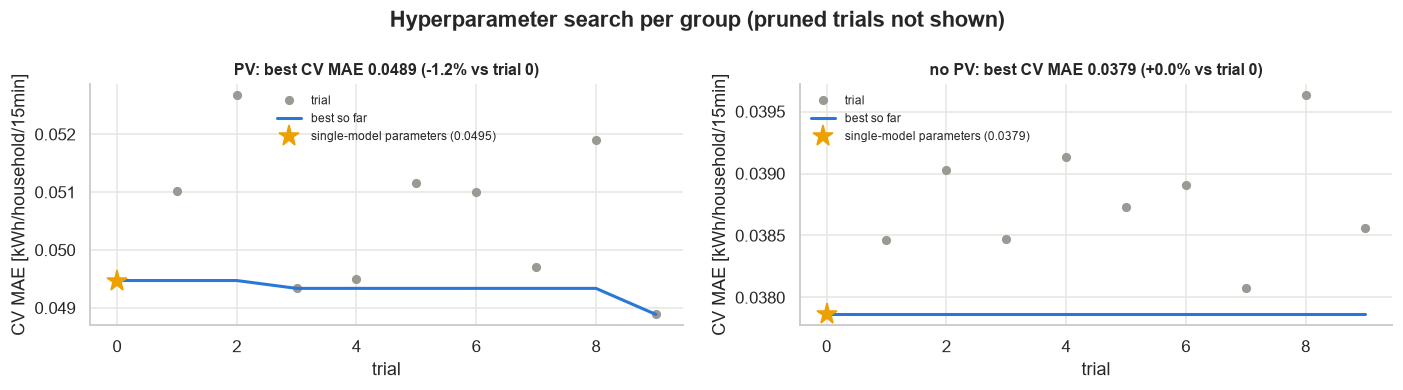

In [20]:
tuned = [g for g in GROUPS if g in split_params] if N_TRIALS_GB > 0 else []
if not tuned:
    print("No hyperparameter search (N_TRIALS_GB = 0): all models use the parameters of the single model.")
else:
    fig, axes = plt.subplots(1, len(tuned), figsize=(6.5 * len(tuned), 3.6), squeeze=False)
    for ax, g in zip(axes[0], tuned):
        t = pd.DataFrame(split_params[g]["trials"])
        t["value"] = pd.to_numeric(t.value, errors="coerce")
        done = t[t.state == "COMPLETE"]
        ax.plot(done.number, done.value, "o", ms=5, color=C_GREY, label="trial")
        ax.plot(done.number, done.value.cummin(), color=C_BLUE, label="best so far")
        v0 = t.loc[t.number == 0, "value"].iloc[0]
        ax.plot([0], [v0], "*", ms=14, color=C_YELLOW, label=f"single-model parameters ({v0:.4f})")
        ax.set_title(f"{g}: best CV MAE {done.value.min():.4f} ({100 * (done.value.min() / v0 - 1):+.1f}% vs trial 0)",
                     fontsize=10.5)
        ax.set_xlabel("trial"); ax.set_ylabel("CV MAE [kWh/household/15min]"); ax.legend(fontsize=8)
    plt.suptitle("Hyperparameter search per group (pruned trials not shown)", fontweight="bold")
    plt.tight_layout(); plt.show()

### 4.2 Final models
All three models are trained on the full training period. The split forecast is the sum of the two group forecasts.

In [21]:
def quarter_hours(days):
    return days.repeat(STEPS) + pd.to_timedelta(np.tile(np.arange(STEPS) * 15, len(days)), unit="min")


models, pred_hh, n_prev = {}, {}, {}
for g in GROUPS:
    t0 = time.time()
    models[g] = gb_from(gb_params[g]).fit(train[g][FEATURES], train[g].y.to_numpy())
    timings[f"fit {g}"] = time.time() - t0
    pred_hh[g] = models[g].predict(test[g][FEATURES]).reshape(-1, STEPS)
    n_prev[g] = test[g].n_contract_prev.to_numpy().reshape(-1, STEPS)      # portfolio size known at forecast time
    print(f"{g:6s}: trained in {timings[f'fit {g}']:.0f}s")

actual_total = test["all"].total.to_numpy().reshape(-1, STEPS)          # original target of _quick_test.ipynb
group_actual = {g: test[g].total.to_numpy().reshape(-1, STEPS) for g in ["PV", "no PV"]}
group_forecast = {g: pred_hh[g] * n_prev[g] for g in ["PV", "no PV"]}
pred_total = {
    "Baseline (t-7d)": test["all"].baseline_total.to_numpy().reshape(-1, STEPS),
    "Persistence": test["all"].persist_total.to_numpy().reshape(-1, STEPS),
    SINGLE: pred_hh["all"] * n_prev["all"],
    SPLIT: group_forecast["PV"] + group_forecast["no PV"],
}
MODELS, BASELINES = list(pred_total), ["Baseline (t-7d)", "Persistence"]

ref_file = RESULTS / "test_forecasts_15min_quick_test.csv"
if ref_file.exists():
    ref = pd.read_csv(ref_file)
    ref = ref.set_index(pd.to_datetime(ref.timestamp, utc=True).dt.tz_convert(TZ))["forecast_Gradient boosting"]
    mine = pd.Series(pred_total[SINGLE].ravel(), index=quarter_hours(test_days))
    common = mine.index.intersection(ref.index)
    print(f"Single model vs. saved forecasts of _quick_test.ipynb: {len(common):,d} common quarter-hours, "
          f"max. abs. difference {np.abs(mine[common] - ref[common]).max():.2e} kWh")

all   : trained in 34s
PV    : trained in 8s
no PV : trained in 34s
Single model vs. saved forecasts of _quick_test.ipynb: 22,944 common quarter-hours, max. abs. difference 5.68e-14 kWh


## 5. Comparison on the test period (last 20%)
Same metrics as in `_quick_test.ipynb`, all for the **aggregated load of all households** in kWh per 15 min. The
additional column *Skill vs single model* is `1 − MAE / MAE(GB single model)`: positive = the split approach is better.

,MAE [kWh],RMSE [kWh],nMAE [%],MAPE [%],R²,Bias [%],Daily energy error [%],Daily peak error [%],Skill vs best baseline [%],Skill vs single model [%]
Baseline (t-7d),22.96,34.03,19.48,18.14,0.716,-1.88,14.36,12.29,-21.14,-58.84
Persistence,18.95,27.66,16.08,16.14,0.813,-0.44,10.33,9.73,0.00,-31.12
GB single model,14.45,20.43,12.26,12.78,0.898,3.11,8.85,7.40,23.73,0.00
GB PV split,13.96,20.00,11.84,12.11,0.902,2.11,8.04,7.12,26.34,3.42


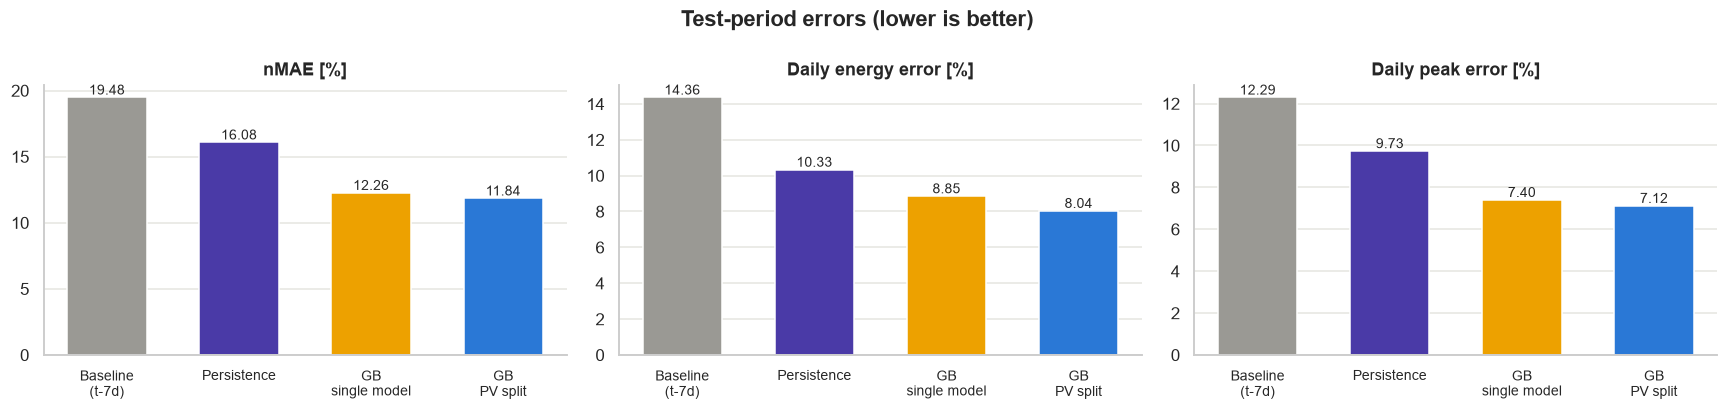

In [22]:
def evaluate(y, p):
    e = p - y
    return {"MAE [kWh]": np.abs(e).mean(), "RMSE [kWh]": np.sqrt((e ** 2).mean()),
            "nMAE [%]": 100 * np.abs(e).mean() / y.mean(), "MAPE [%]": 100 * np.mean(np.abs(e) / y),
            "R²": r2_score(y.ravel(), p.ravel()), "Bias [%]": 100 * e.mean() / y.mean(),
            "Daily energy error [%]": 100 * np.mean(np.abs(e.sum(1)) / y.sum(1)),
            "Daily peak error [%]": 100 * np.mean(np.abs(p.max(1) - y.max(1)) / y.max(1))}


res = pd.DataFrame({m: evaluate(actual_total, pred_total[m]) for m in MODELS}).T
res["Skill vs best baseline [%]"] = 100 * (1 - res["MAE [kWh]"] / res.loc[BASELINES, "MAE [kWh]"].min())
res["Skill vs single model [%]"] = 100 * (1 - res["MAE [kWh]"] / res.loc[SINGLE, "MAE [kWh]"])
display(res.style.format("{:.2f}").format("{:.3f}", subset=["R²"])
        .background_gradient(cmap="Blues_r", subset=["nMAE [%]", "Daily energy error [%]"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, col in zip(axes, ["nMAE [%]", "Daily energy error [%]", "Daily peak error [%]"]):
    v = res.loc[MODELS, col]
    ax.bar(range(len(v)), v.values, color=[MODEL_COLORS[m] for m in MODELS], width=.6)
    for i, x in enumerate(v.values):
        ax.text(i, x, f"{x:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(v)), [m.replace(" (", "\n(").replace("GB ", "GB\n") for m in MODELS], fontsize=9)
    ax.set_title(col); ax.grid(axis="x", visible=False)
plt.suptitle("Test-period errors (lower is better)", fontweight="bold")
plt.tight_layout(); plt.show()

### 5.1 Is the difference significant?
Moving-block bootstrap over the test days (blocks of 7 days, as in `_quick_test.ipynb`) for the difference
*split − single*. Negative = the split approach is better; if the 95% interval contains 0, the test period cannot tell
the two approaches apart.

In [23]:
rng = np.random.default_rng(SEED)
B, L = 2000, 7
n_days = len(test_days)
starts = rng.integers(0, n_days - L + 1, size=(B, int(np.ceil(n_days / L))))
boot_idx = (starts[:, :, None] + np.arange(L)).reshape(B, -1)[:, :n_days]
daily_err = {
    "MAE [kWh]": lambda p: np.abs(p - actual_total).mean(1),
    "Daily energy error [kWh]": lambda p: np.abs((p - actual_total).sum(1)),
    "Daily peak error [kWh]": lambda p: np.abs(p.max(1) - actual_total.max(1)),
}
sig = {}
for name, f in daily_err.items():
    diff = f(pred_total[SPLIT]) - f(pred_total[SINGLE])
    boot = diff[boot_idx].mean(1)
    sig[name] = {"single model": f(pred_total[SINGLE]).mean(), "PV split": f(pred_total[SPLIT]).mean(),
                 "Δ split − single": diff.mean(), "95% CI low": np.percentile(boot, 2.5),
                 "95% CI high": np.percentile(boot, 97.5), "P(split better)": (boot < 0).mean(),
                 "days split better [%]": 100 * (diff < 0).mean()}
pd.DataFrame(sig).T.style.format("{:,.2f}")

,single model,PV split,Δ split − single,95% CI low,95% CI high,P(split better),days split better [%]
MAE [kWh],14.45,13.96,-0.49,-0.83,-0.18,1.00,55.23
Daily energy error [kWh],"1,032.98",960.90,-72.07,-118.53,-27.72,1.00,54.39
Daily peak error [kWh],13.30,13.23,-0.07,-0.70,0.62,0.58,52.30


### 5.2 Cross-check on the CV folds of the training period
The test period covers only ~8 months (July – February). As a second, independent check both approaches are refitted
on the four expanding-window folds (four validation quarters inside the training period) and compared on the aggregated
load. Note: the hyperparameters of all models were selected on these folds, so the absolute errors are slightly
optimistic — for both approaches alike. Runs only with `RUN_CV_COMPARISON = True`.

In [24]:
if RUN_CV_COMPARISON:
    t0 = time.time()
    act_tr = train["all"].total.to_numpy()
    cv_rows = []
    for k, (tr, va) in enumerate(folds):
        fc = {}
        for g in GROUPS:
            m = gb_from(gb_params[g]).fit(train[g][FEATURES].iloc[tr], train[g].y.to_numpy()[tr])
            fc[g] = m.predict(train[g][FEATURES].iloc[va]) * train[g].n_contract_prev.to_numpy()[va]
        a = act_tr[va]
        for name, p in [(SINGLE, fc["all"]), (SPLIT, fc["PV"] + fc["no PV"])]:
            cv_rows.append({"fold": f"{k + 1}: {fold_days[k]}", "model": name, "nMAE [%]": 100 * np.abs(p - a).mean() / a.mean()})
    timings["CV comparison"] = time.time() - t0
    cv_cmp = pd.DataFrame(cv_rows).pivot(index="fold", columns="model", values="nMAE [%]")[[SINGLE, SPLIT]]
    cv_cmp.loc["mean"] = cv_cmp.mean()
    cv_cmp["Δ split − single [pp]"] = cv_cmp[SPLIT] - cv_cmp[SINGLE]
    display(cv_cmp.style.format("{:,.2f}"))
else:
    print("Skipped (RUN_CV_COMPARISON = False).")

Skipped (RUN_CV_COMPARISON = False).


### 5.3 Accuracy per group
How well is each group's own load forecast? For comparison, the **single model** is also applied to the group's
features (its forecast per household × the group's portfolio size): this shows whether a group-specific model learns
something that the model for the portfolio mean cannot.

In [25]:
grp_rows = {}
for g in ["PV", "no PV"]:
    act = group_actual[g]
    single_on_group = models["all"].predict(test[g][FEATURES]).reshape(-1, STEPS) * n_prev[g]
    for name, p in [("own group model", group_forecast[g]), ("single model on group features", single_on_group)]:
        r = evaluate(act, p)
        grp_rows[(g, name)] = {"share of portfolio load [%]": 100 * act.sum() / actual_total.sum(),
                               **{k: r[k] for k in ["MAE [kWh]", "nMAE [%]", "Bias [%]", "Daily energy error [%]",
                                                    "Daily peak error [%]"]}}
pd.DataFrame(grp_rows).T.style.format("{:,.2f}")

### 5.4 Where does the split approach help?
The target-day sunshine used below is the **measured** portfolio-weighted sunshine duration of day D — used only to
group the test days, it was never a model input.

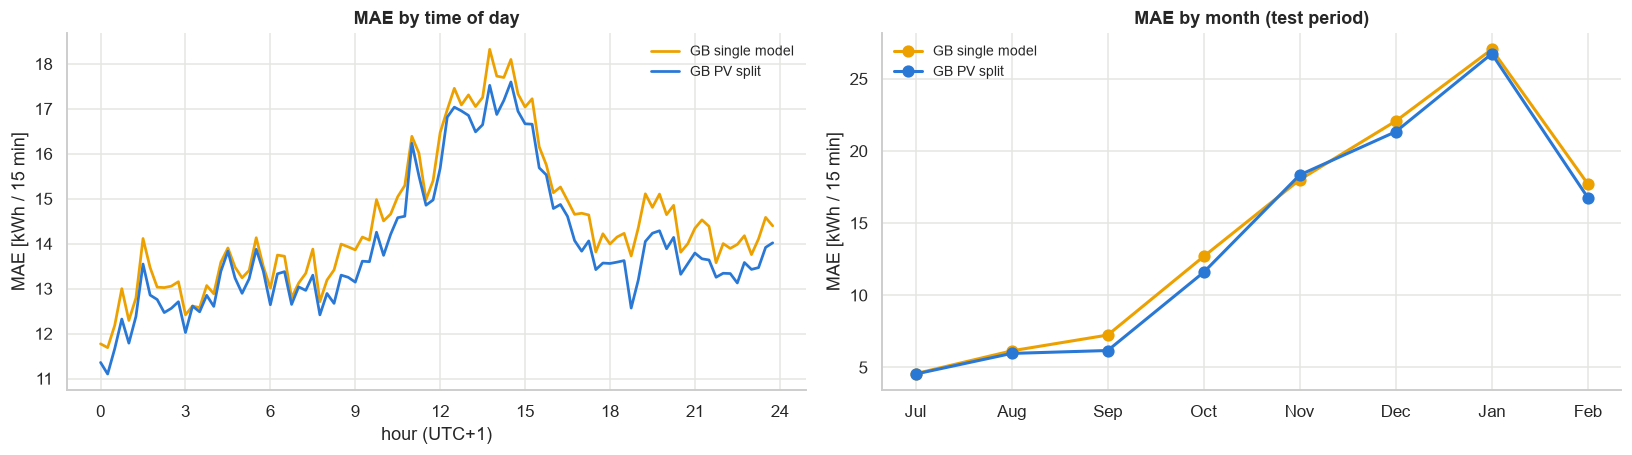

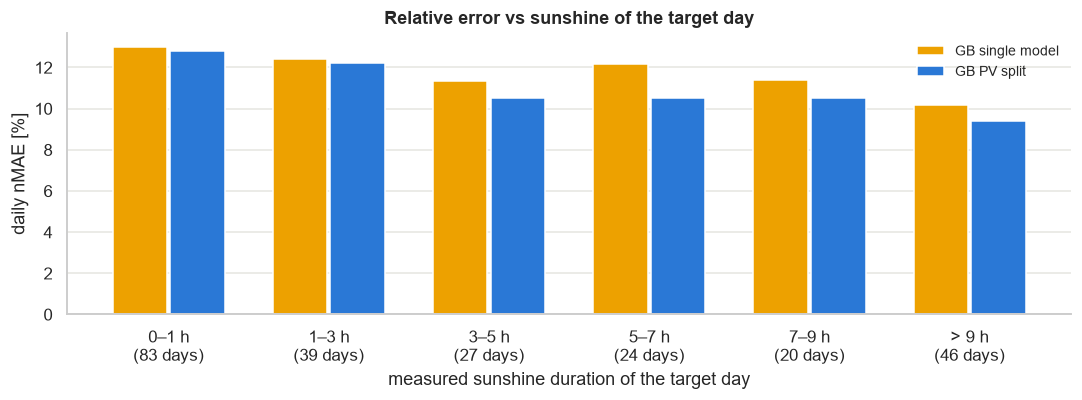

,GB single model,GB PV split,test days
0–1 h,13.02,12.81,83
1–3 h,12.40,12.21,39
3–5 h,11.34,10.51,27
5–7 h,12.17,10.54,24
7–9 h,11.40,10.49,20
> 9 h,10.17,9.40,46


In [26]:
hours = np.arange(STEPS) / 4
test_month = np.array([d.month for d in test_days])
order = sorted(set(test_month), key=lambda x: (x < test_days[0].month, x))
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
for m in [SINGLE, SPLIT]:
    err = np.abs(pred_total[m] - actual_total)
    axes[0].plot(hours, err.mean(0), color=MODEL_COLORS[m], lw=1.8, label=m)
    by_month = pd.Series(err.mean(1)).groupby(test_month).mean()
    axes[1].plot(range(len(order)), by_month[order].values, marker="o", ms=7, color=MODEL_COLORS[m], label=m)
axes[0].set_title("MAE by time of day"); axes[0].set_xlabel("hour (UTC+1)"); axes[0].set_ylabel("MAE [kWh / 15 min]")
axes[0].set_xticks(range(0, 25, 3)); axes[0].legend(fontsize=9)
axes[1].set_xticks(range(len(order)), [pd.Timestamp(2000, k, 1).strftime("%b") for k in order])
axes[1].set_title("MAE by month (test period)"); axes[1].set_ylabel("MAE [kWh / 15 min]"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

test_sun = (P["all"].Wx["sunshine"].sum(axis=1) / 4).reindex(test_days)        # evaluation only — not a model input
sun_bins = pd.cut(test_sun.values, bins=[-0.1, 1, 3, 5, 7, 9, 16],
                  labels=["0–1 h", "1–3 h", "3–5 h", "5–7 h", "7–9 h", "> 9 h"])
by_sun = pd.DataFrame({m: pd.Series(100 * np.abs(pred_total[m] - actual_total).mean(1) / actual_total.mean(1))
                       .groupby(sun_bins).mean() for m in [SINGLE, SPLIT]})
by_sun["test days"] = pd.Series(sun_bins).value_counts().reindex(by_sun.index)
fig, ax = plt.subplots(figsize=(10, 3.8))
xpos = np.arange(len(by_sun))
for i, m in enumerate([SINGLE, SPLIT]):
    ax.bar(xpos + (i - .5) * .36, by_sun[m], width=.34, color=MODEL_COLORS[m], label=m)
ax.set_xticks(xpos, [f"{b}\n({n} days)" for b, n in zip(by_sun.index, by_sun["test days"])])
ax.set_xlabel("measured sunshine duration of the target day"); ax.set_ylabel("daily nMAE [%]")
ax.set_title("Relative error vs sunshine of the target day"); ax.legend(fontsize=9); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
by_sun.style.format("{:,.2f}").format("{:,.0f}", subset=["test days"])

### 5.5 Example days
Top: aggregated portfolio load. Bottom: the PV group alone (actual vs. its own model). Days: the sunniest and the most
overcast test day between May and September, and the coldest test day.

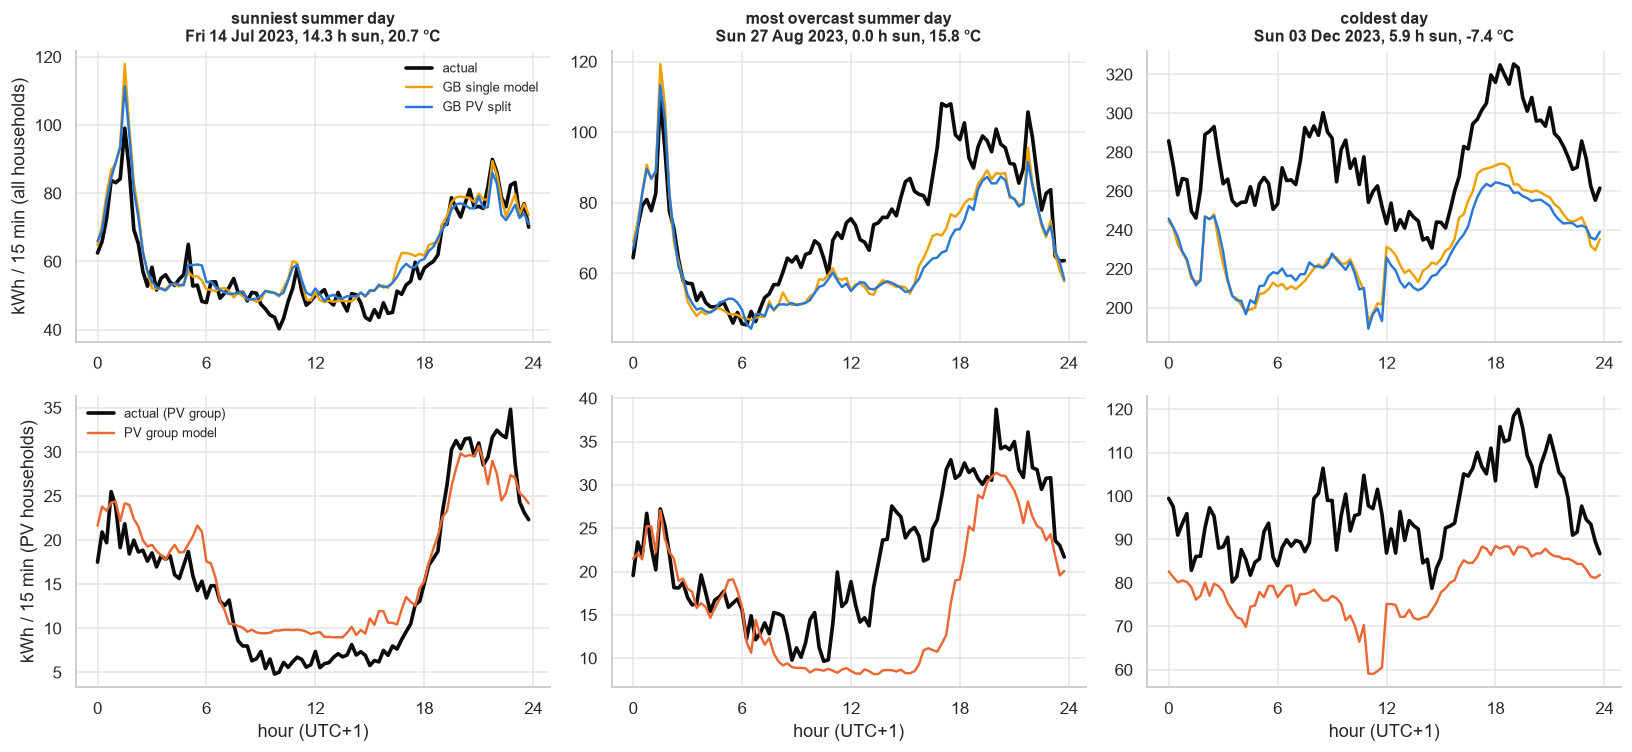

In [27]:
test_temp = P["all"].Wx["temp"].mean(axis=1).reindex(test_days)                # evaluation only
summer_days = test_days[np.isin(test_month, [5, 6, 7, 8, 9])]
picks = {"coldest day": test_temp.idxmin()}
if len(summer_days):
    picks = {"sunniest summer day": test_sun[summer_days].idxmax(),
             "most overcast summer day": test_sun[summer_days].idxmin(), **picks}
fig, axes = plt.subplots(2, len(picks), figsize=(5 * len(picks), 7), squeeze=False)
for j, (label, d) in enumerate(picks.items()):
    i = test_days.get_loc(d)
    ax = axes[0, j]
    ax.plot(hours, actual_total[i], color=C_INK, lw=2.4, label="actual")
    for m in [SINGLE, SPLIT]:
        ax.plot(hours, pred_total[m][i], color=MODEL_COLORS[m], lw=1.6, label=m)
    ax.set_title(f"{label}\n{d:%a %d %b %Y}, {test_sun[d]:.1f} h sun, {test_temp[d]:.1f} °C", fontsize=10.5)
    ax = axes[1, j]
    ax.plot(hours, group_actual["PV"][i], color=C_INK, lw=2.4, label="actual (PV group)")
    ax.plot(hours, group_forecast["PV"][i], color=GROUP_COLORS["PV"], lw=1.6, label="PV group model")
    ax.set_xlabel("hour (UTC+1)")
    for ax in axes[:, j]:
        ax.set_xticks(range(0, 25, 6))
axes[0, 0].set_ylabel("kWh / 15 min (all households)"); axes[1, 0].set_ylabel("kWh / 15 min (PV households)")
axes[0, 0].legend(fontsize=8.5); axes[1, 0].legend(fontsize=8.5)
plt.tight_layout(); plt.show()

In [28]:
OUT_FILE = RESULTS / "test_forecasts_15min_pv_split.csv"
out = pd.DataFrame({"timestamp": quarter_hours(test_days), "actual_total_kWh": actual_total.ravel(),
                    "actual_PV_kWh": group_actual["PV"].ravel(), "actual_noPV_kWh": group_actual["no PV"].ravel(),
                    "n_households_known_at_forecast": n_prev["all"].ravel(),
                    "n_PV_households_known_at_forecast": n_prev["PV"].ravel()})
for m in MODELS:
    out[f"forecast_{m}"] = pred_total[m].ravel()
out["forecast_PV_group"] = group_forecast["PV"].ravel()
out["forecast_noPV_group"] = group_forecast["no PV"].ravel()
out.to_csv(OUT_FILE, index=False)
print(f"Saved {len(out):,d} rows to {OUT_FILE}")
print("Run times [s]:", {k: round(v) for k, v in timings.items()})

Saved 22,944 rows to results\test_forecasts_15min_pv_split.csv
Run times [s]: {'read households': 59, 'data preparation': 4, 'HPO PV': 369, 'HPO no PV': 432, 'fit all': 34, 'fit PV': 8, 'fit no PV': 34}


## 6. Conclusions

In [29]:
summary = res.loc[MODELS, ["nMAE [%]", "Bias [%]", "Daily energy error [%]", "Daily peak error [%]",
                           "Skill vs best baseline [%]", "Skill vs single model [%]"]]
d = res.loc[SPLIT, "nMAE [%]"] - res.loc[SINGLE, "nMAE [%]"]
print(f"PV classification: {PV_LABEL_SOURCE}, indicator {PV_INDICATOR} | "
      f"{len(GROUPS['PV'])} PV / {len(GROUPS['no PV'])} non-PV households")
print(f"Test nMAE: single model {res.loc[SINGLE, 'nMAE [%]']:.2f}% -> PV split {res.loc[SPLIT, 'nMAE [%]']:.2f}% "
      f"({d:+.2f} pp, P(split better) = {sig['MAE [kWh]']['P(split better)']:.2f})")
if RUN_CV_COMPARISON:
    print(f"CV nMAE (mean of {N_FOLDS} folds): single {cv_cmp.loc['mean', SINGLE]:.2f}% -> "
          f"PV split {cv_cmp.loc['mean', SPLIT]:.2f}%")
summary.style.format("{:,.2f}")

PV classification: metadata_first, indicator midday_dip | 142 PV / 268 non-PV households
Test nMAE: single model 12.26% -> PV split 11.84% (-0.42 pp, P(split better) = 1.00)


,nMAE [%],Bias [%],Daily energy error [%],Daily peak error [%],Skill vs best baseline [%],Skill vs single model [%]
Baseline (t-7d),19.48,-1.88,14.36,12.29,-21.14,-58.84
Persistence,16.08,-0.44,10.33,9.73,0.00,-31.12
GB single model,12.26,3.11,8.85,7.40,23.73,0.00
GB PV split,11.84,2.11,8.04,7.12,26.34,3.42


**How to read the results**
* *Skill vs single model* > 0 and a 95% interval in 5.1 that lies entirely below 0 → the split into PV / non-PV models
  improves the portfolio forecast significantly. The CV comparison in 5.2 (`RUN_CV_COMPARISON = True`) shows whether this
  also holds in other seasons (the test period only covers July – February).
* Section 5.3 shows where a gain comes from: the PV group model should beat the single model applied to the PV
  features clearly (the PV load shape differs most), while for the non-PV group both should be close.
* Section 5.4: a gain should appear mainly around midday and on sunny days — on overcast winter days PV households
  behave like households without PV.

**Limitations and next steps**
* **No weather forecast for day D.** The PV yield of day D depends on its sunshine, which is unknown at gate closure in
  this dataset; the PV model can only learn the typical midday dip and the sunshine of D-1. A sunshine / irradiance
  forecast as input would help the PV model most.
* **Survey-PV households without a dip** (about a third, see 2.3) stay in the PV group with
  `PV_LABEL_SOURCE = "metadata_first"`. `PV_LABEL_SOURCE = "detected_all"` groups all households by their observed
  load shape instead — worth a comparison run.
* The early PV group is small (~15 households in Nov 2020), so its mean load is noisier than the portfolio mean.